In [93]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
df_path = Path("/home/tblanchard/phd/Finsler-Embedding/results/eval_operators_swiss_roll.csv")
df_tot = pd.read_csv(df_path)

In [95]:
col_to_plt = ['admissible', 'cos_V', 'scale_V',
       'relerr_V', 'trace_ratio_Gamma', 'relerr_Gamma', 'relerr_c_norm',
       'relerr_c_norm_all', 'ratio_c_norm_all', 'cos_V_all']

def squarify(n):
    """Return the closest square number greater than or equal to n."""
    return int(np.ceil(np.sqrt(n)))

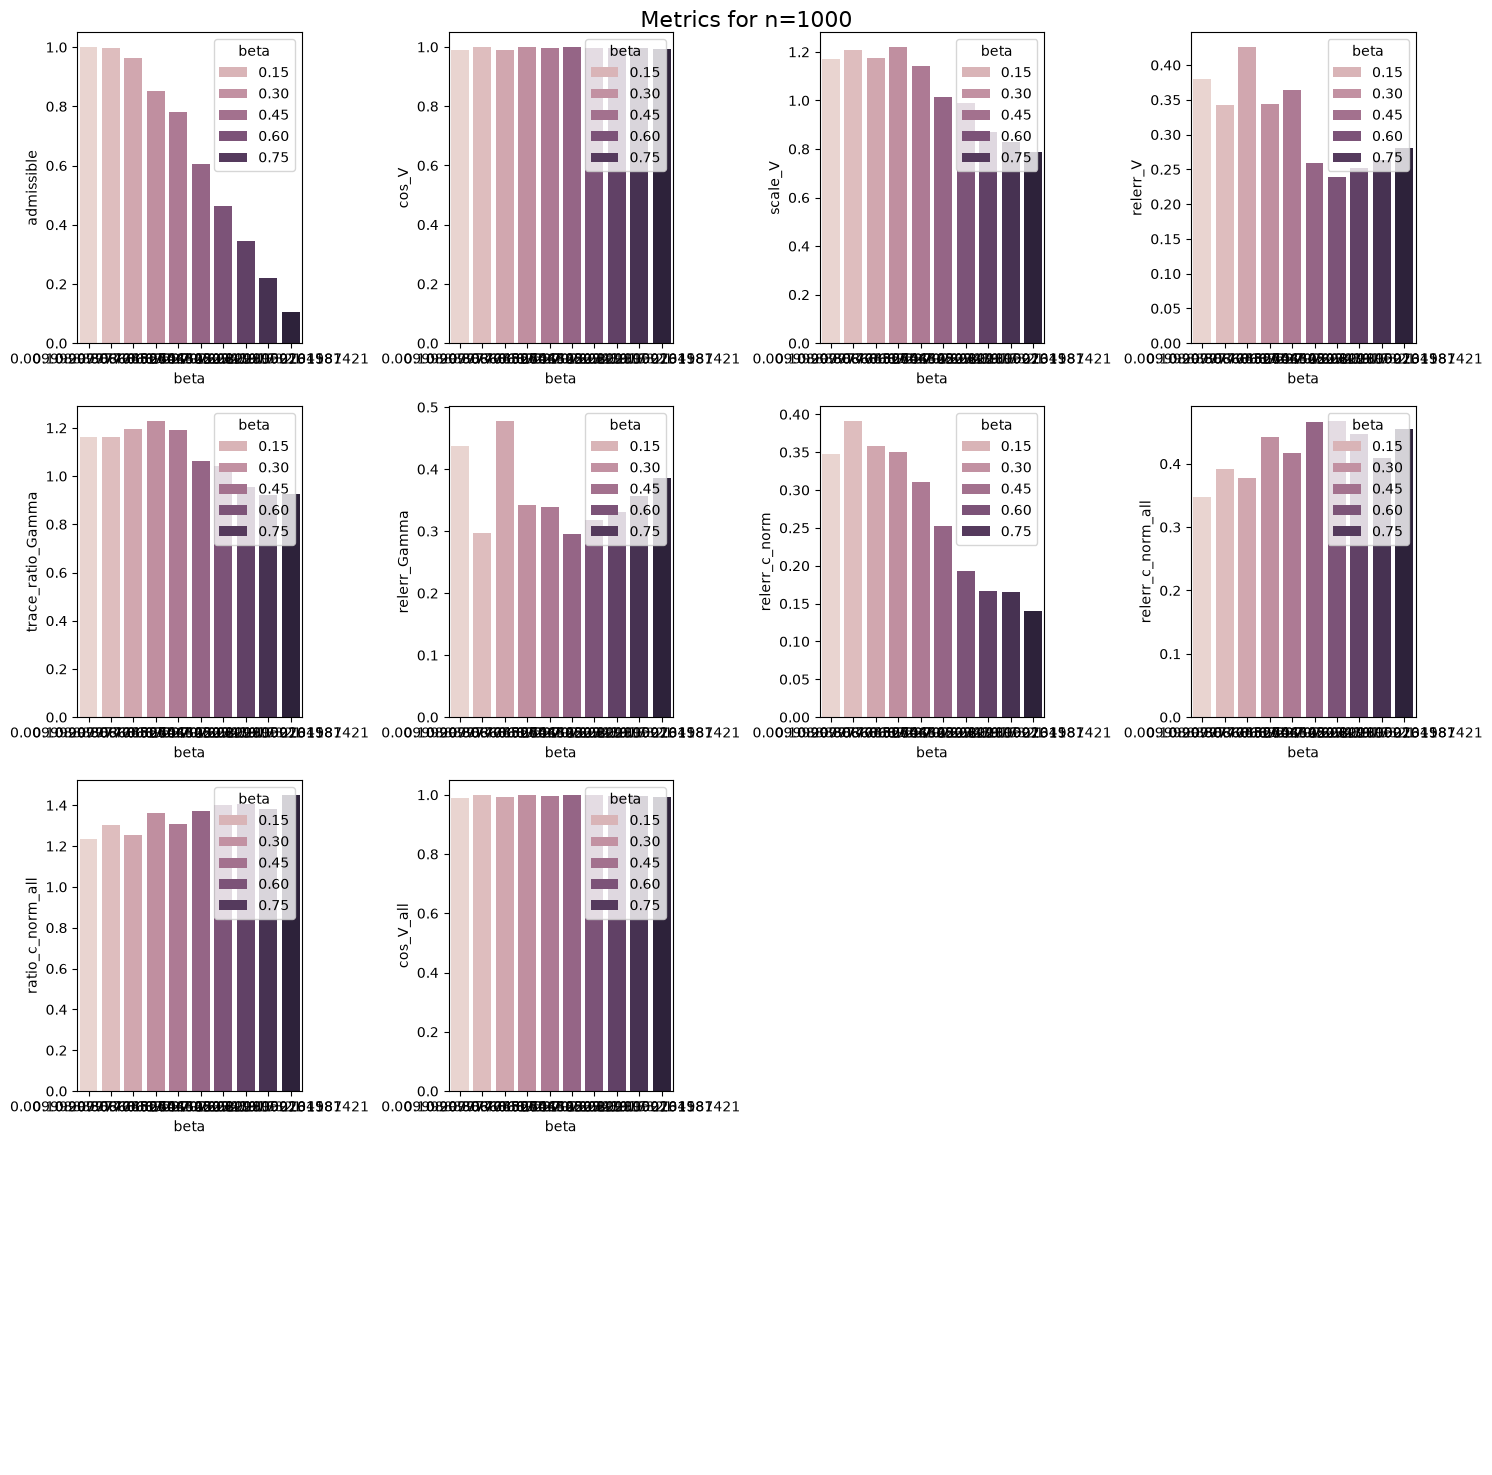

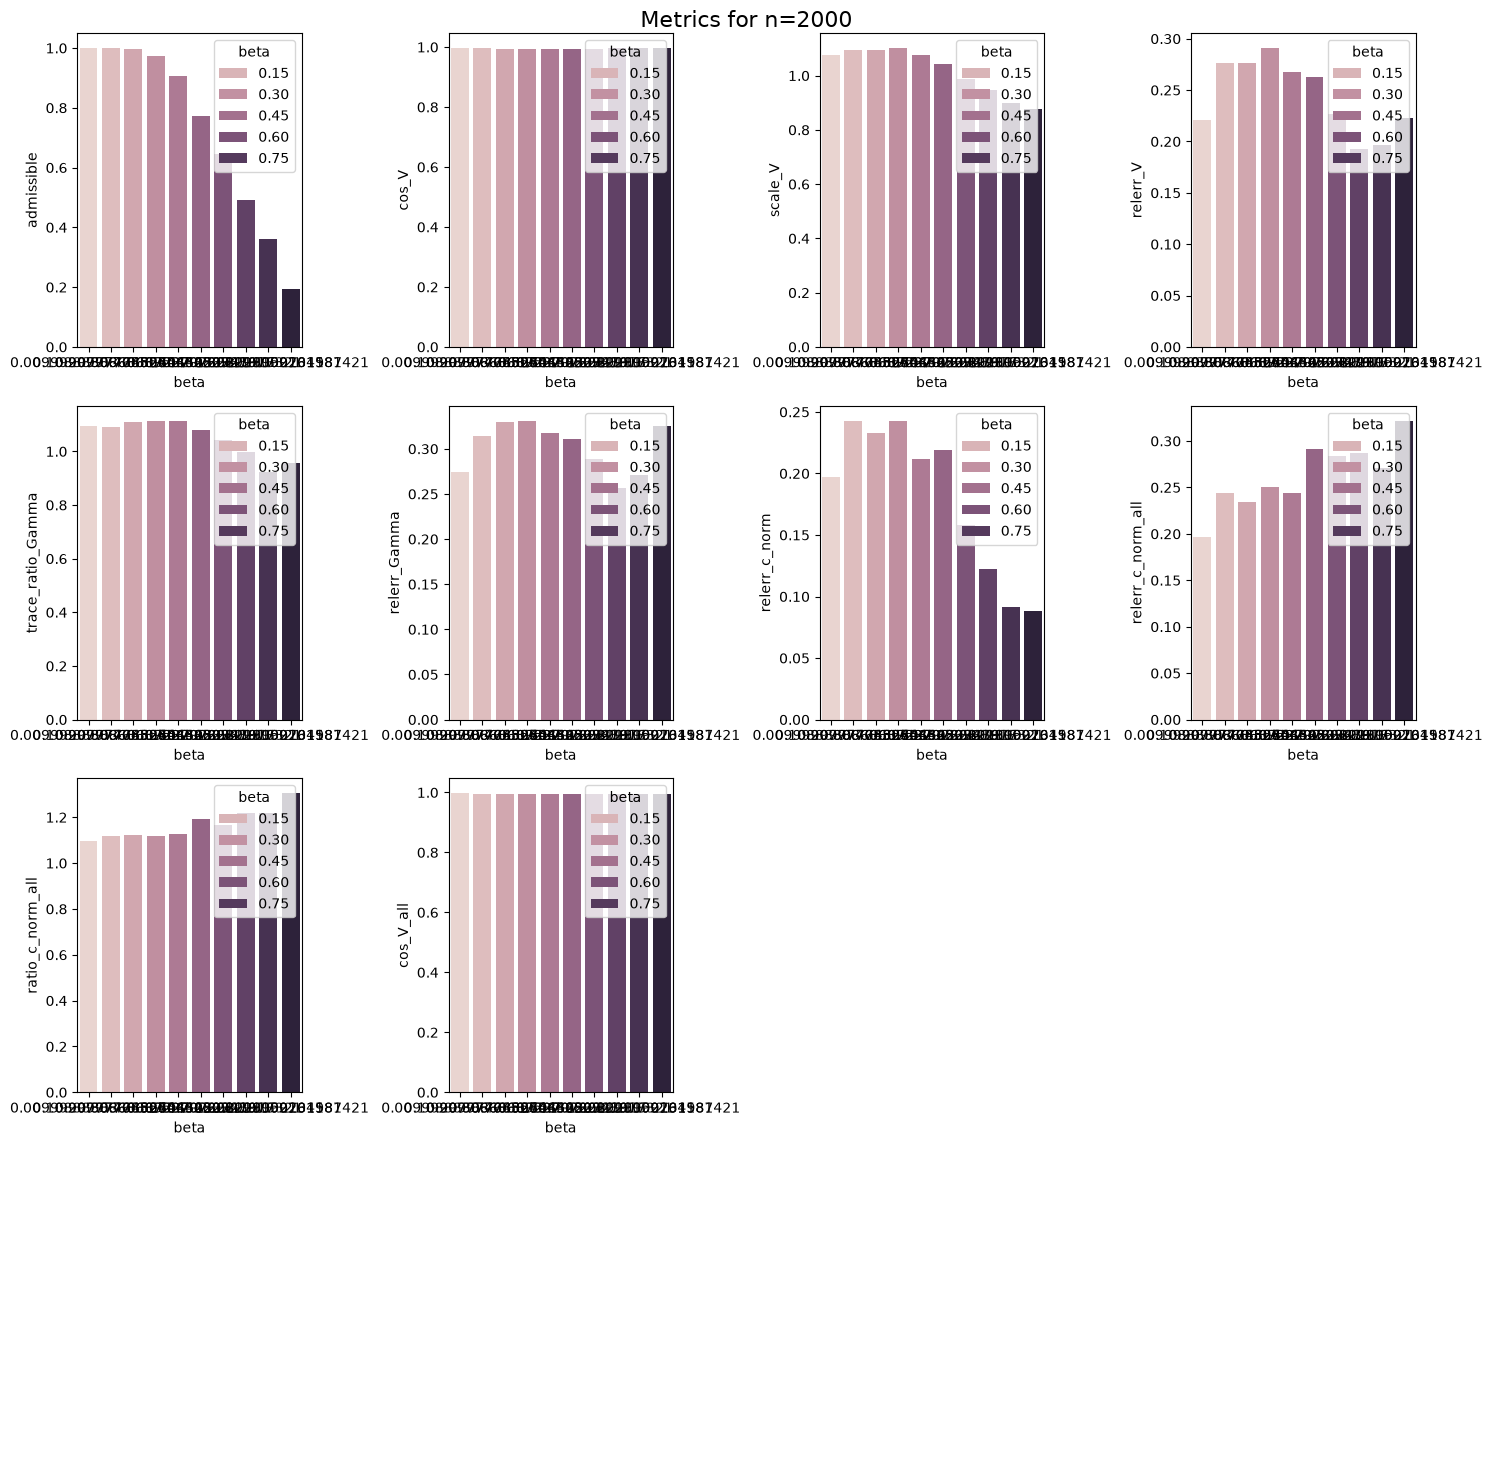

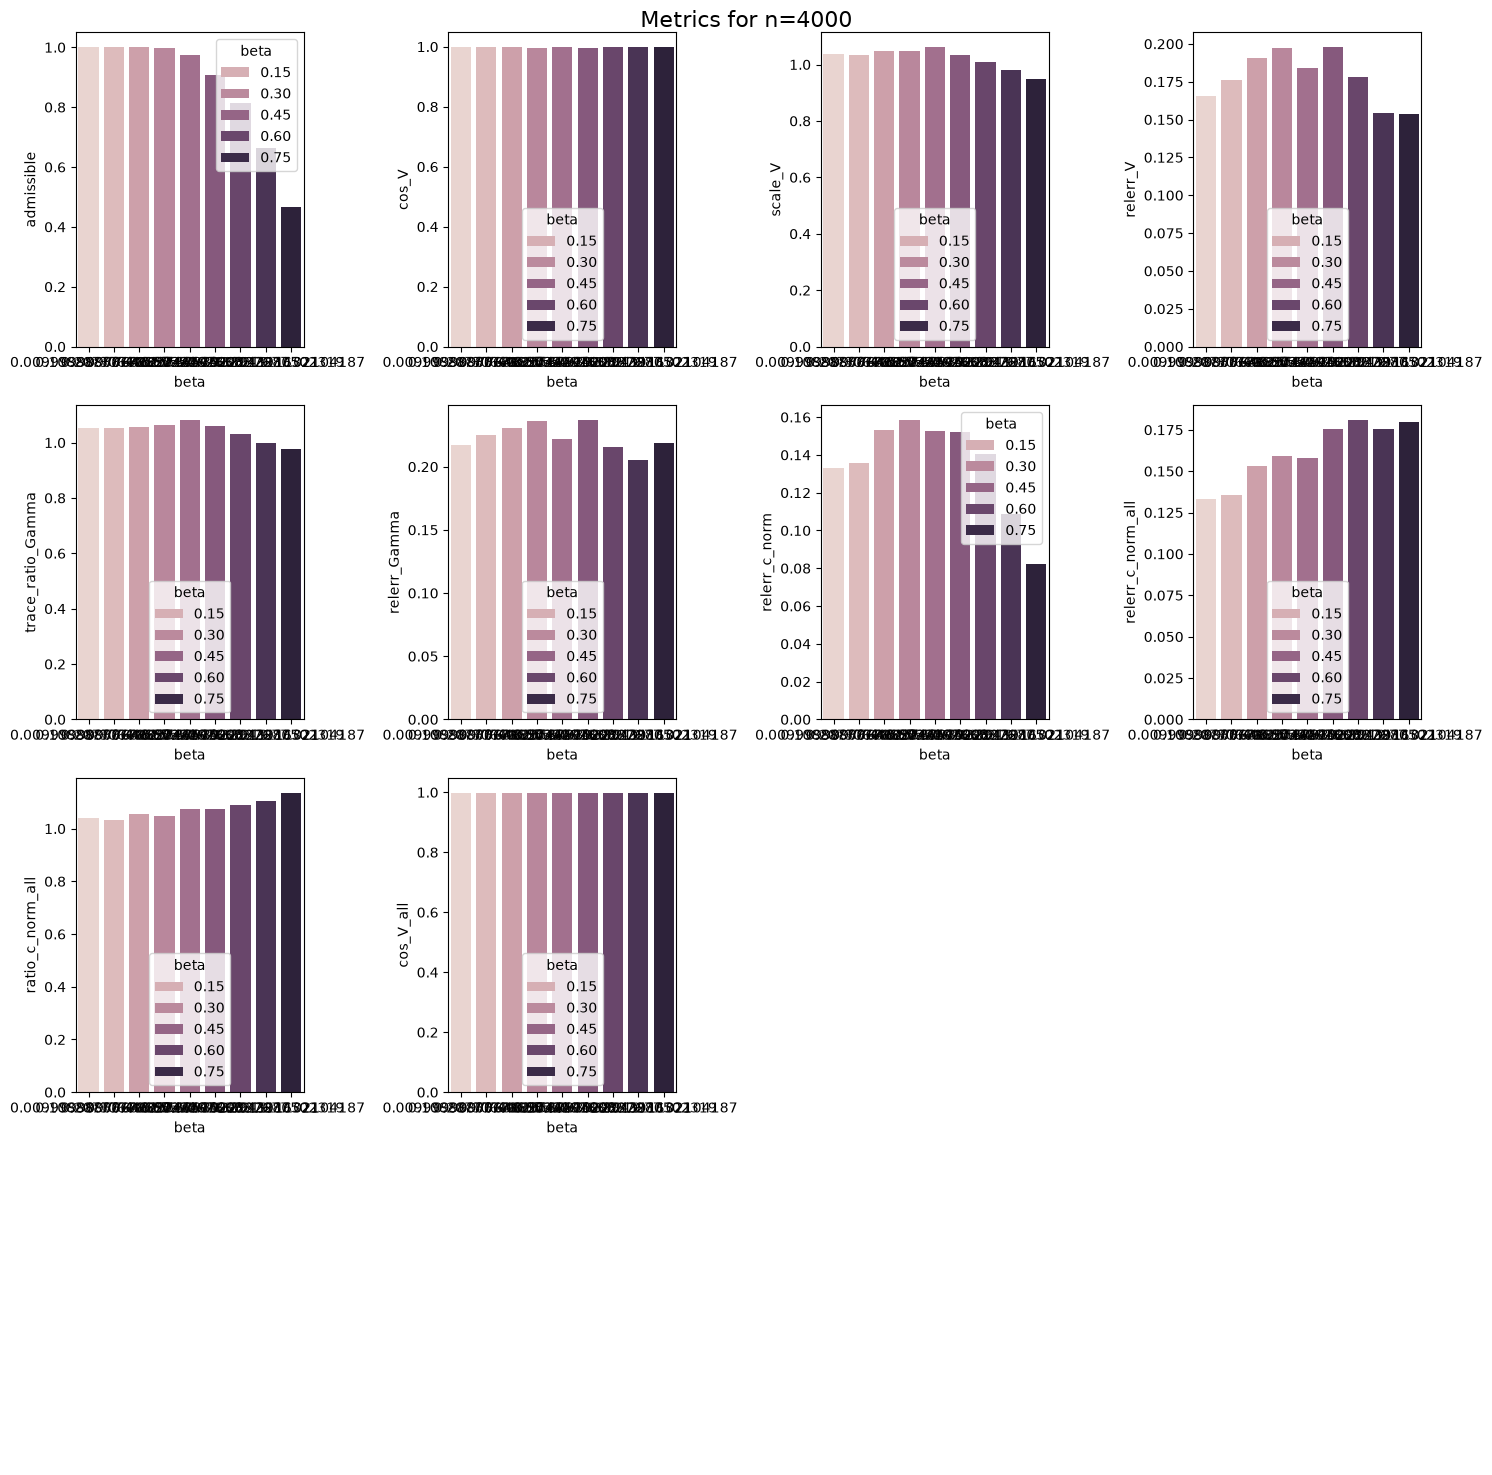

In [96]:
for N in df_tot['n'].unique():
    df_tot_N = df_tot[df_tot['n'] == N]
    fig, axes = plt.subplots(squarify(len(col_to_plt)), squarify(len(col_to_plt)), figsize=(15, 15))
    axes = axes.flatten()
    for i in range(len(col_to_plt)):
        sns.barplot(
            data=df_tot_N,
            x="beta",
            y=col_to_plt[i],
            hue="beta",
            ax=axes[i]
        )
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f"Metrics for n={N}", fontsize=16)
    fig.tight_layout()
    plt.show()

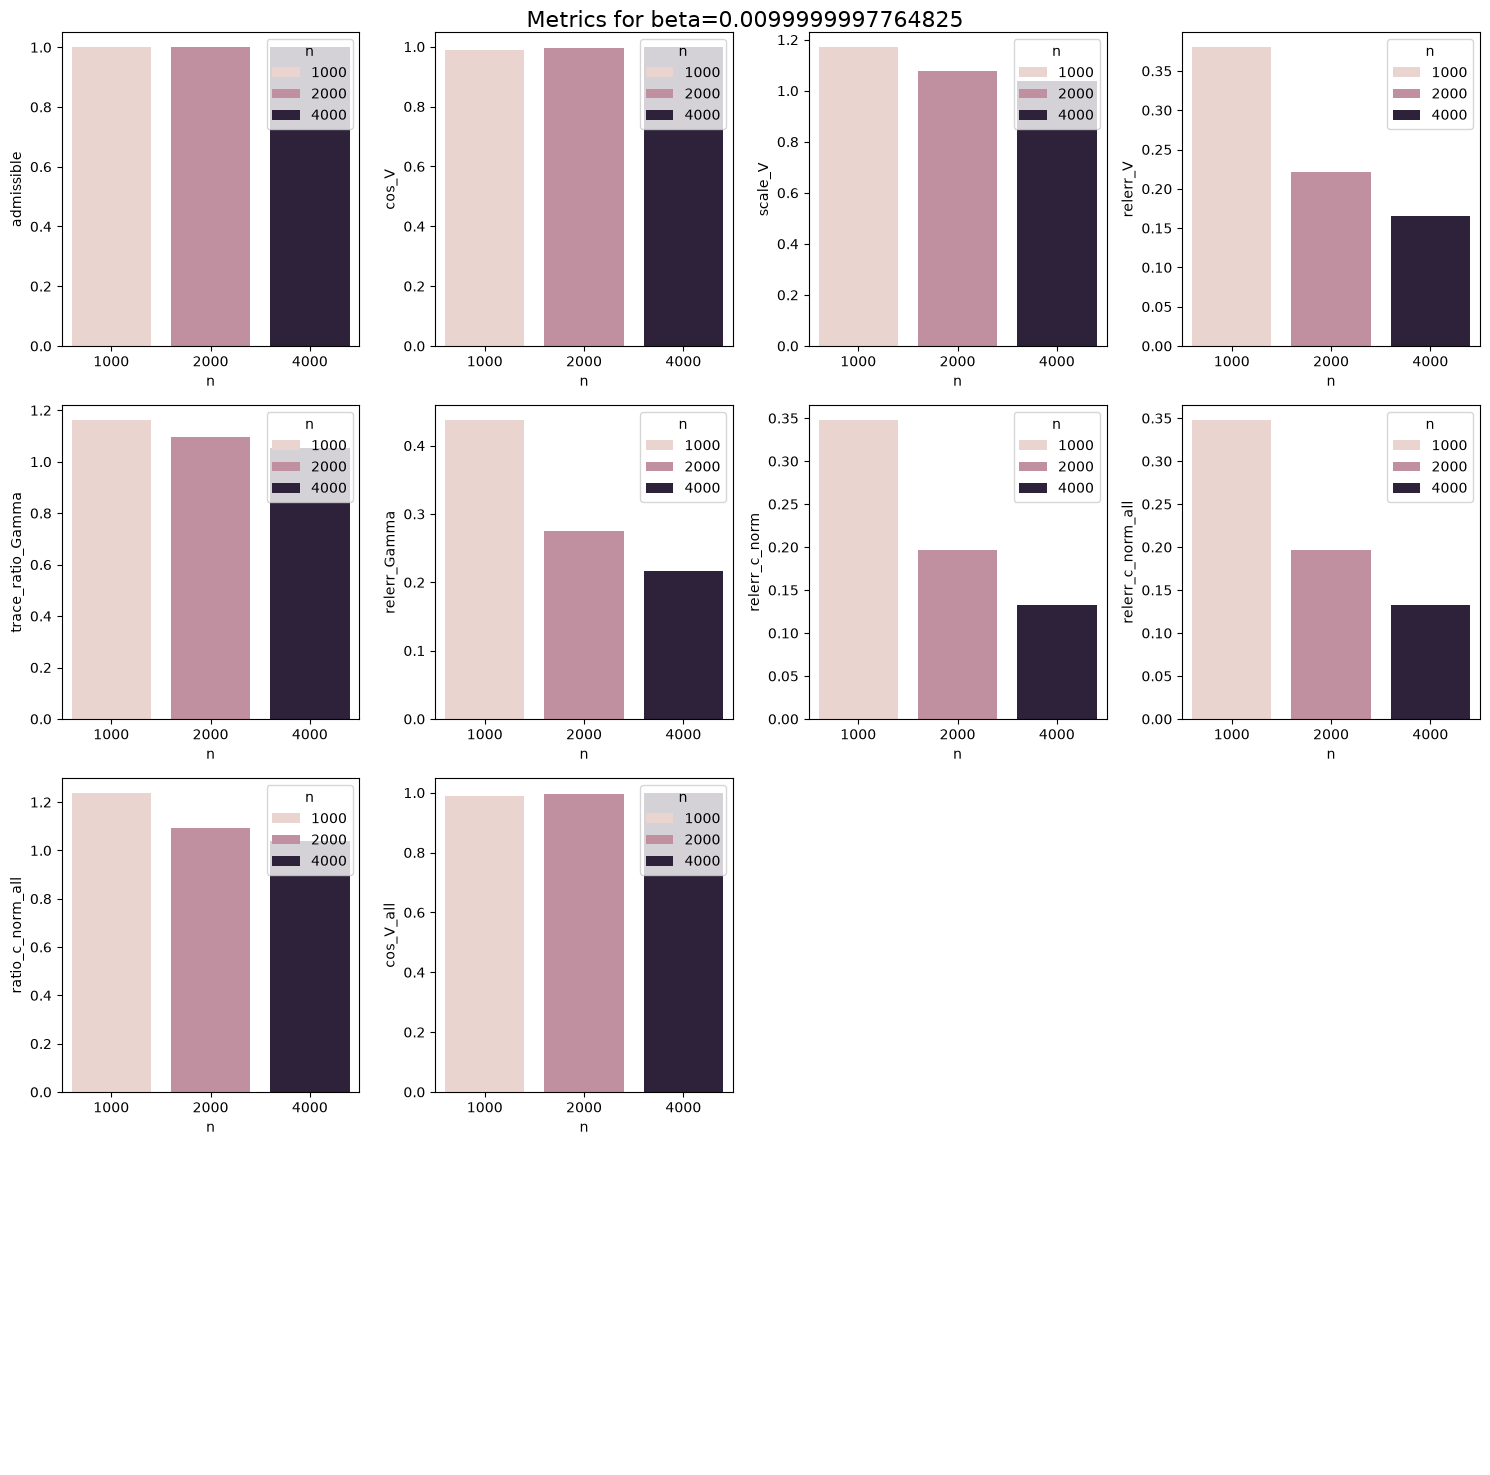

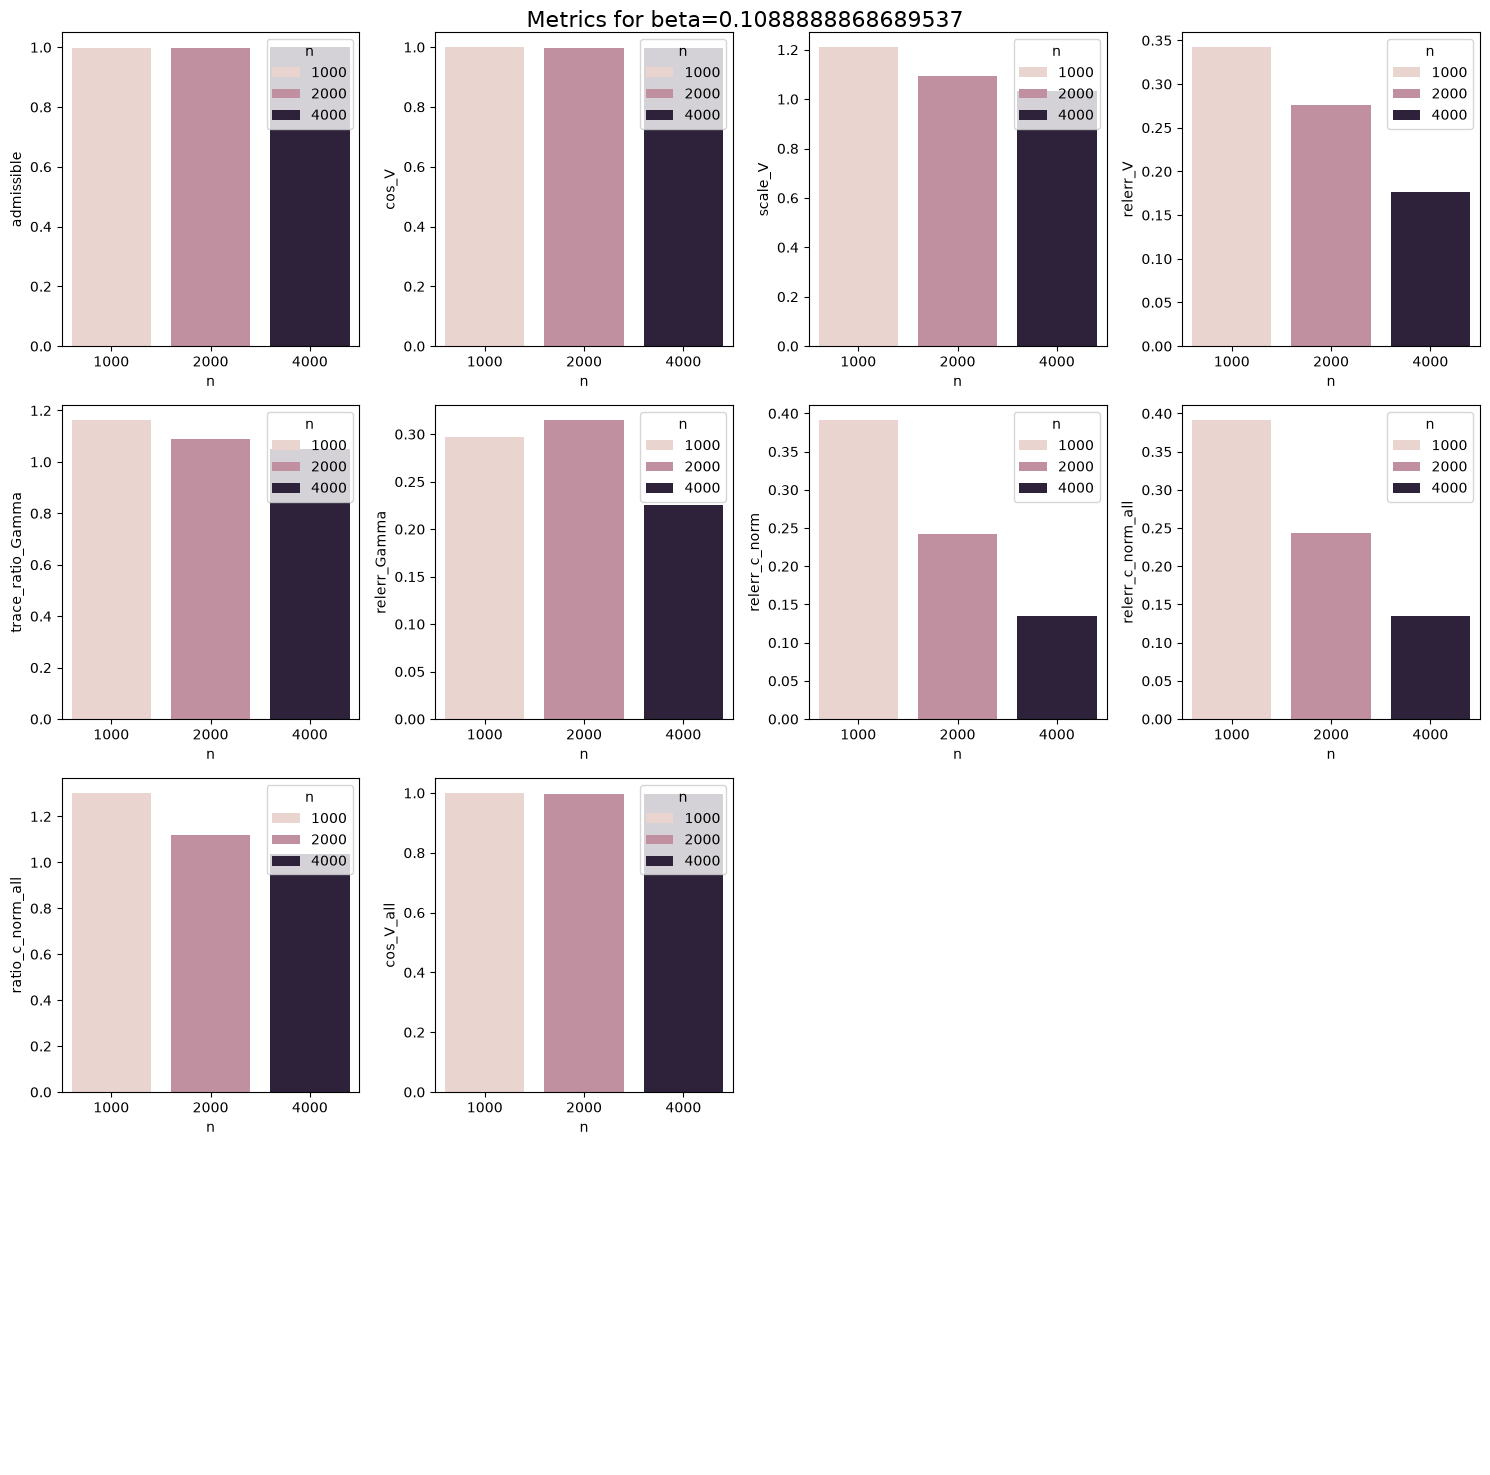

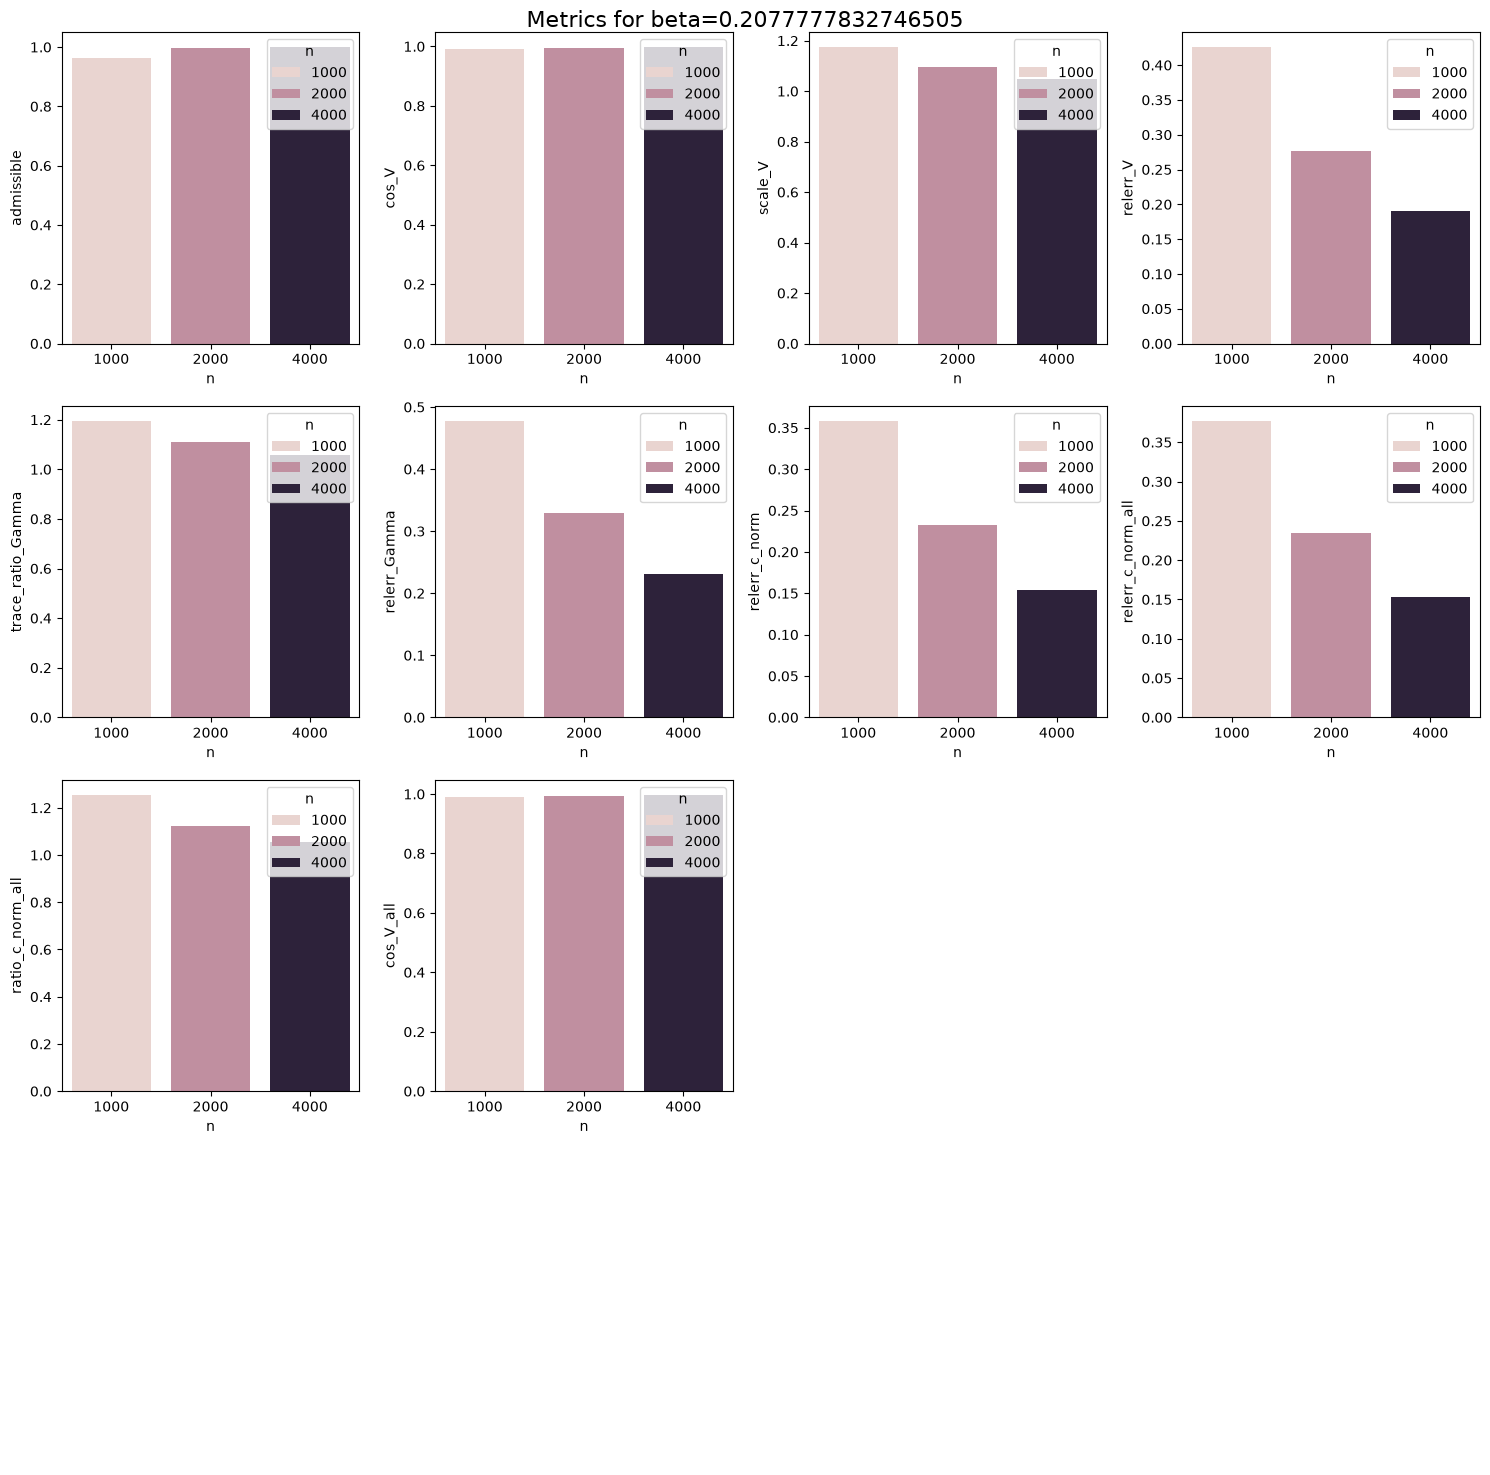

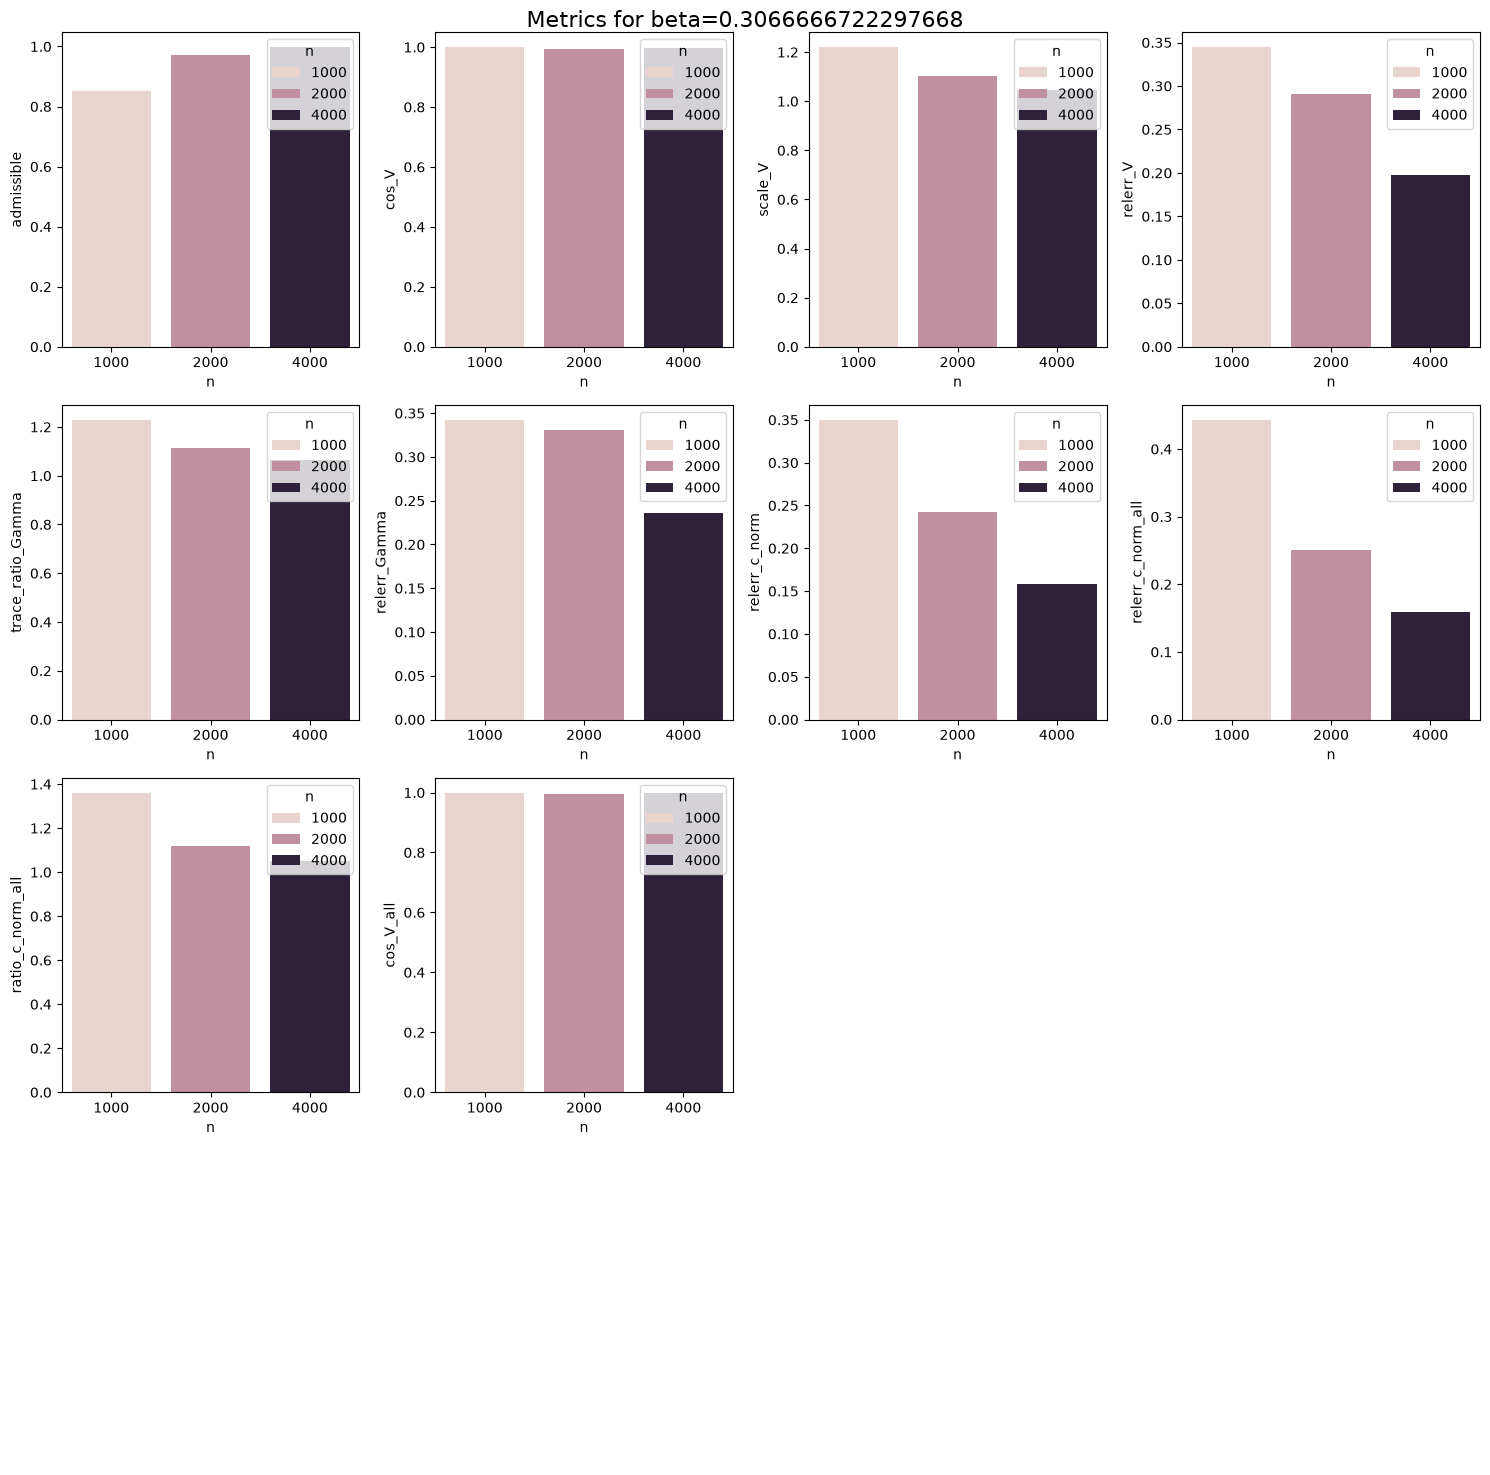

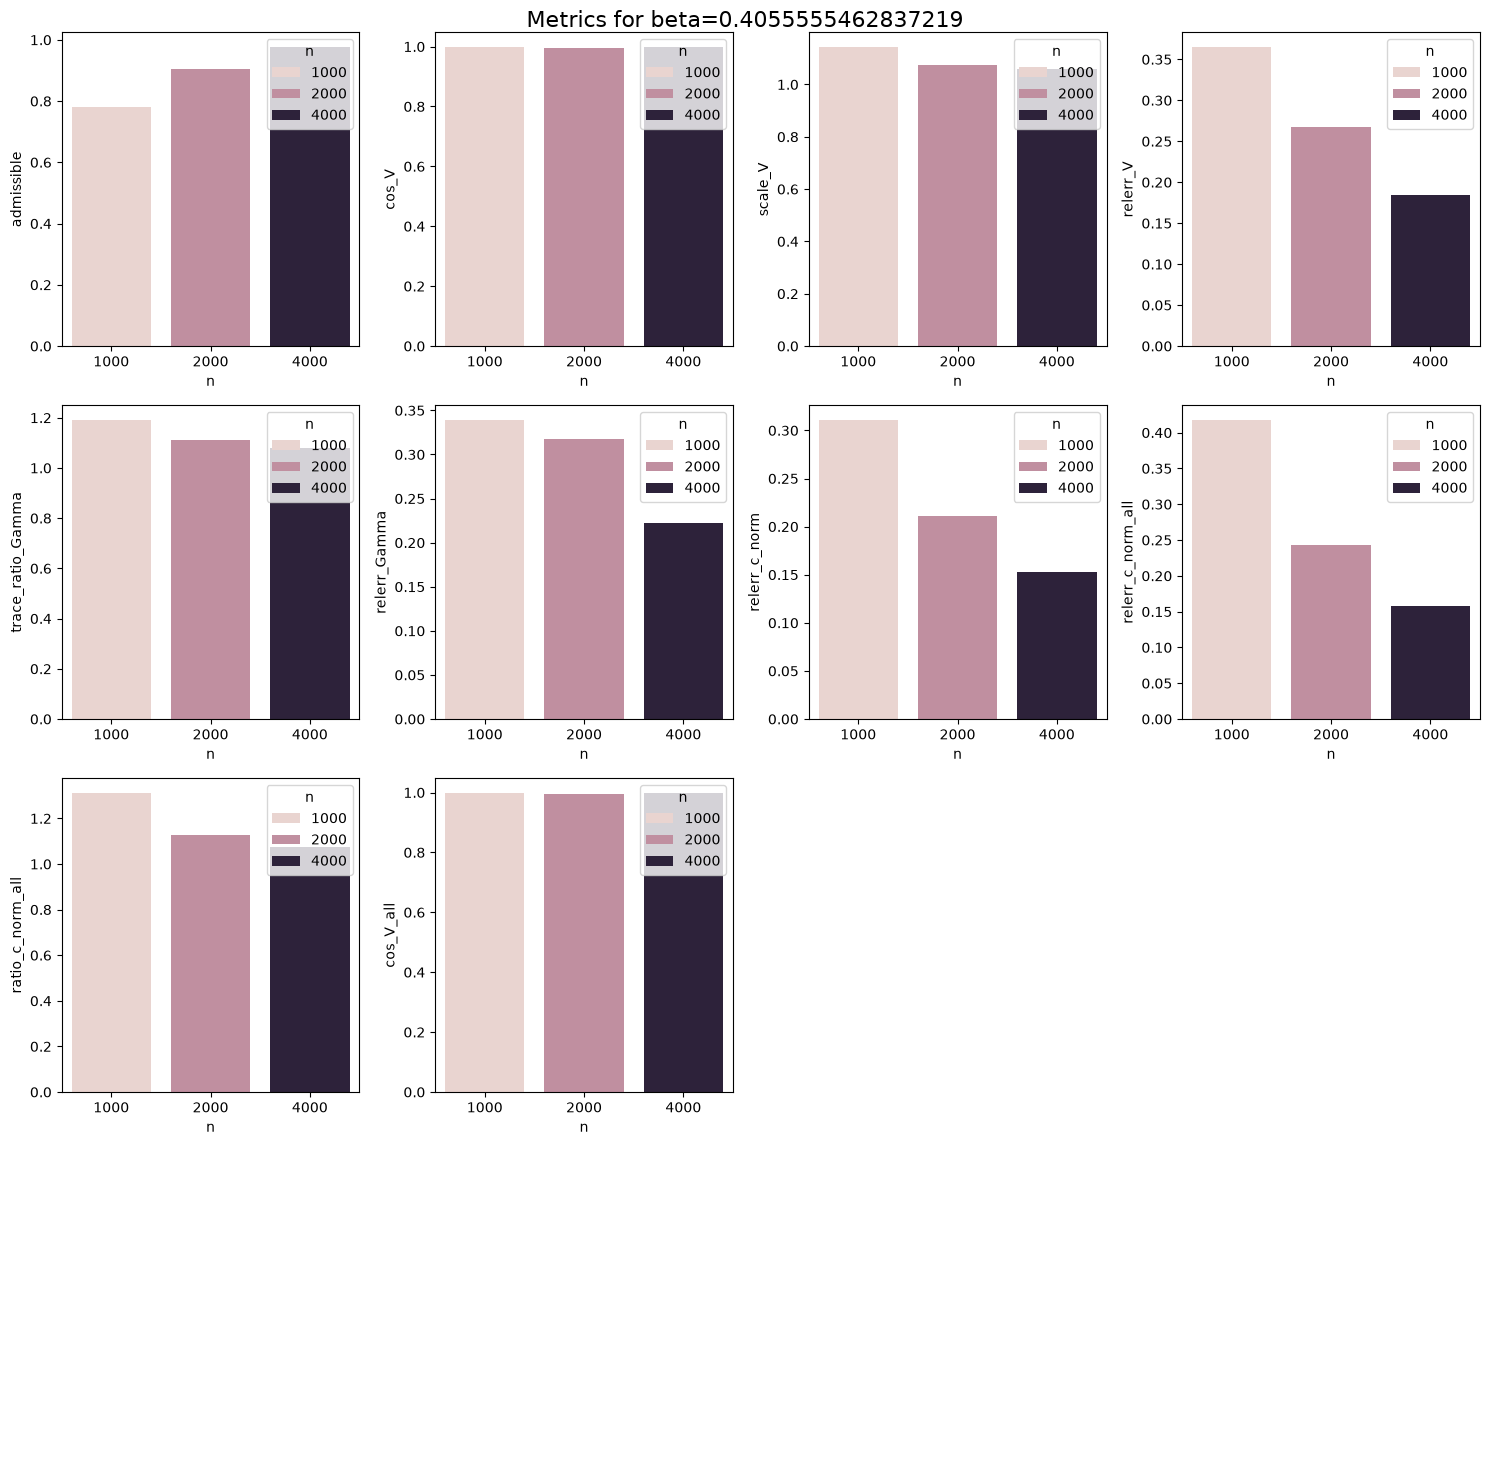

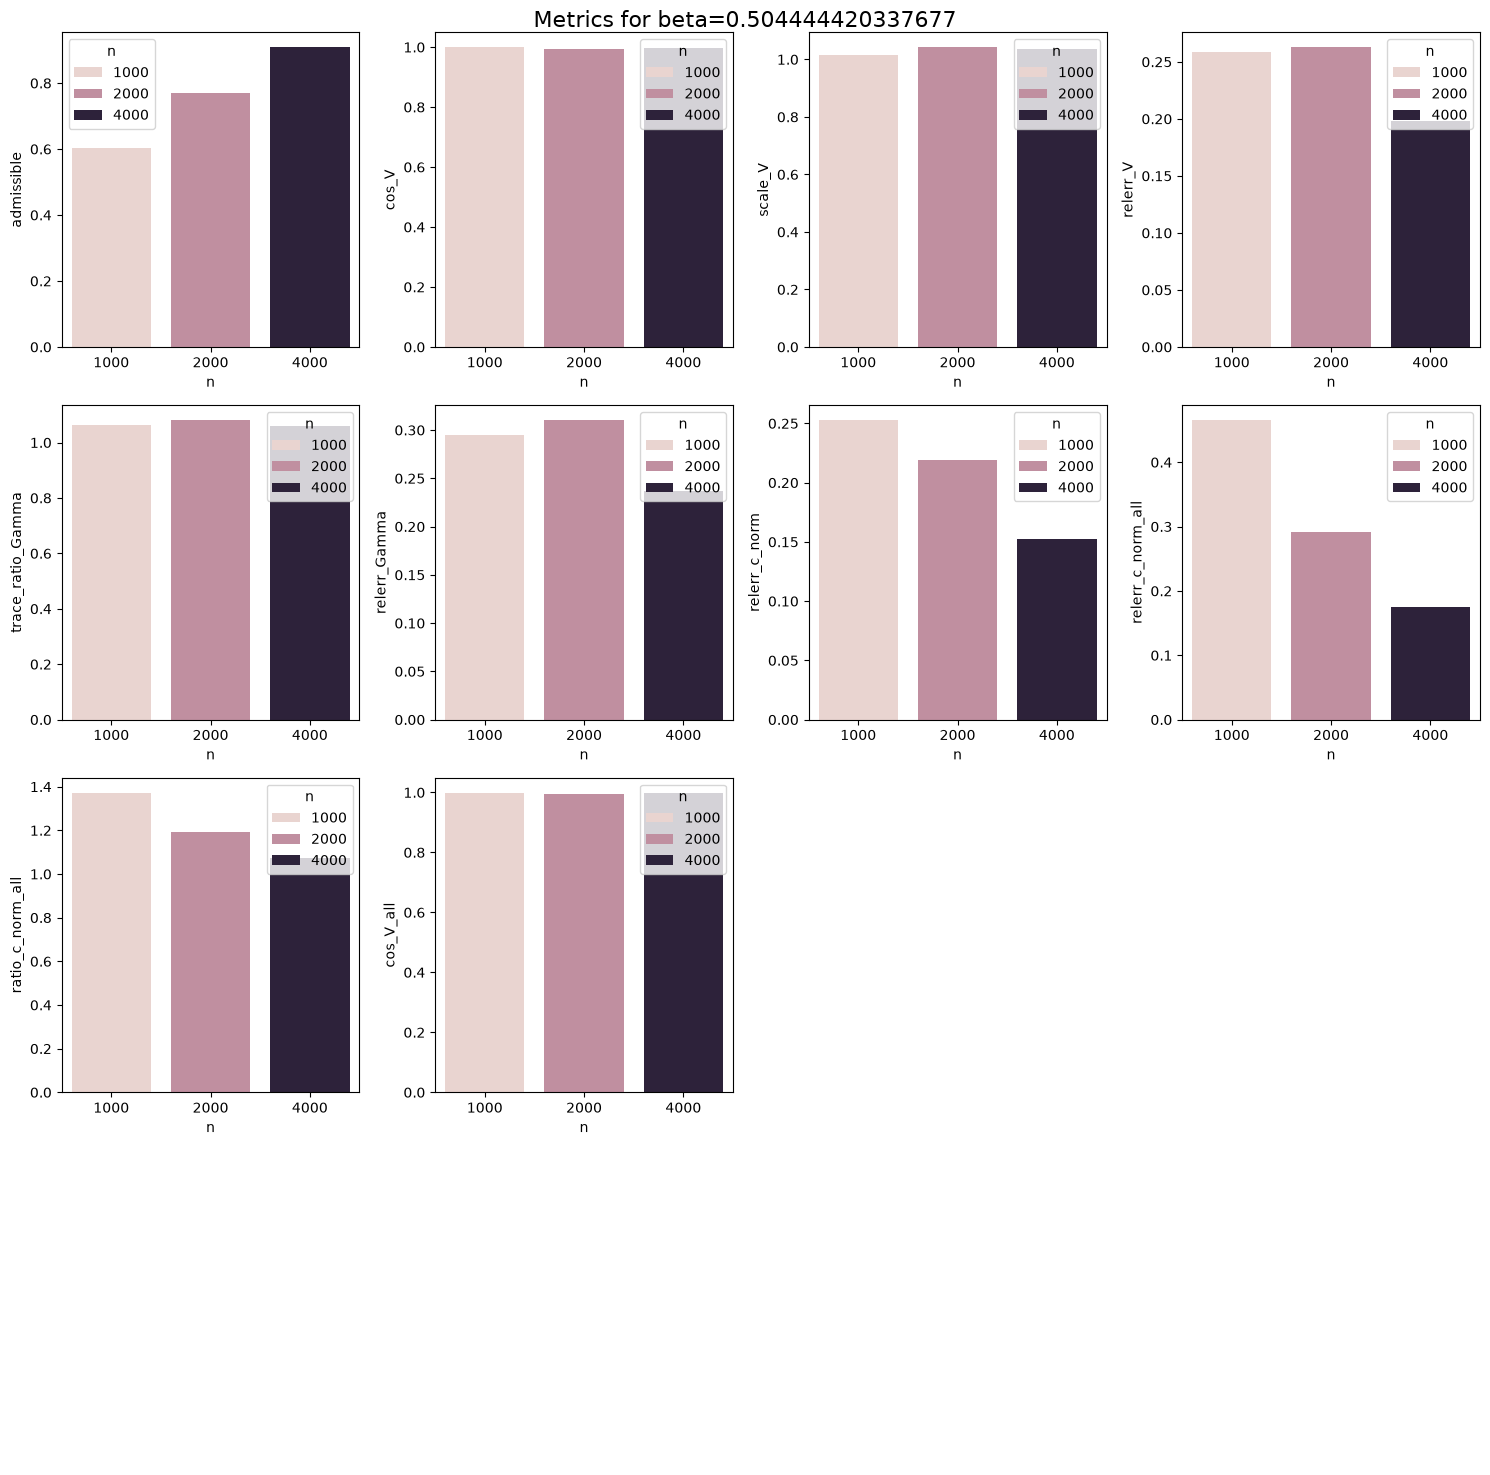

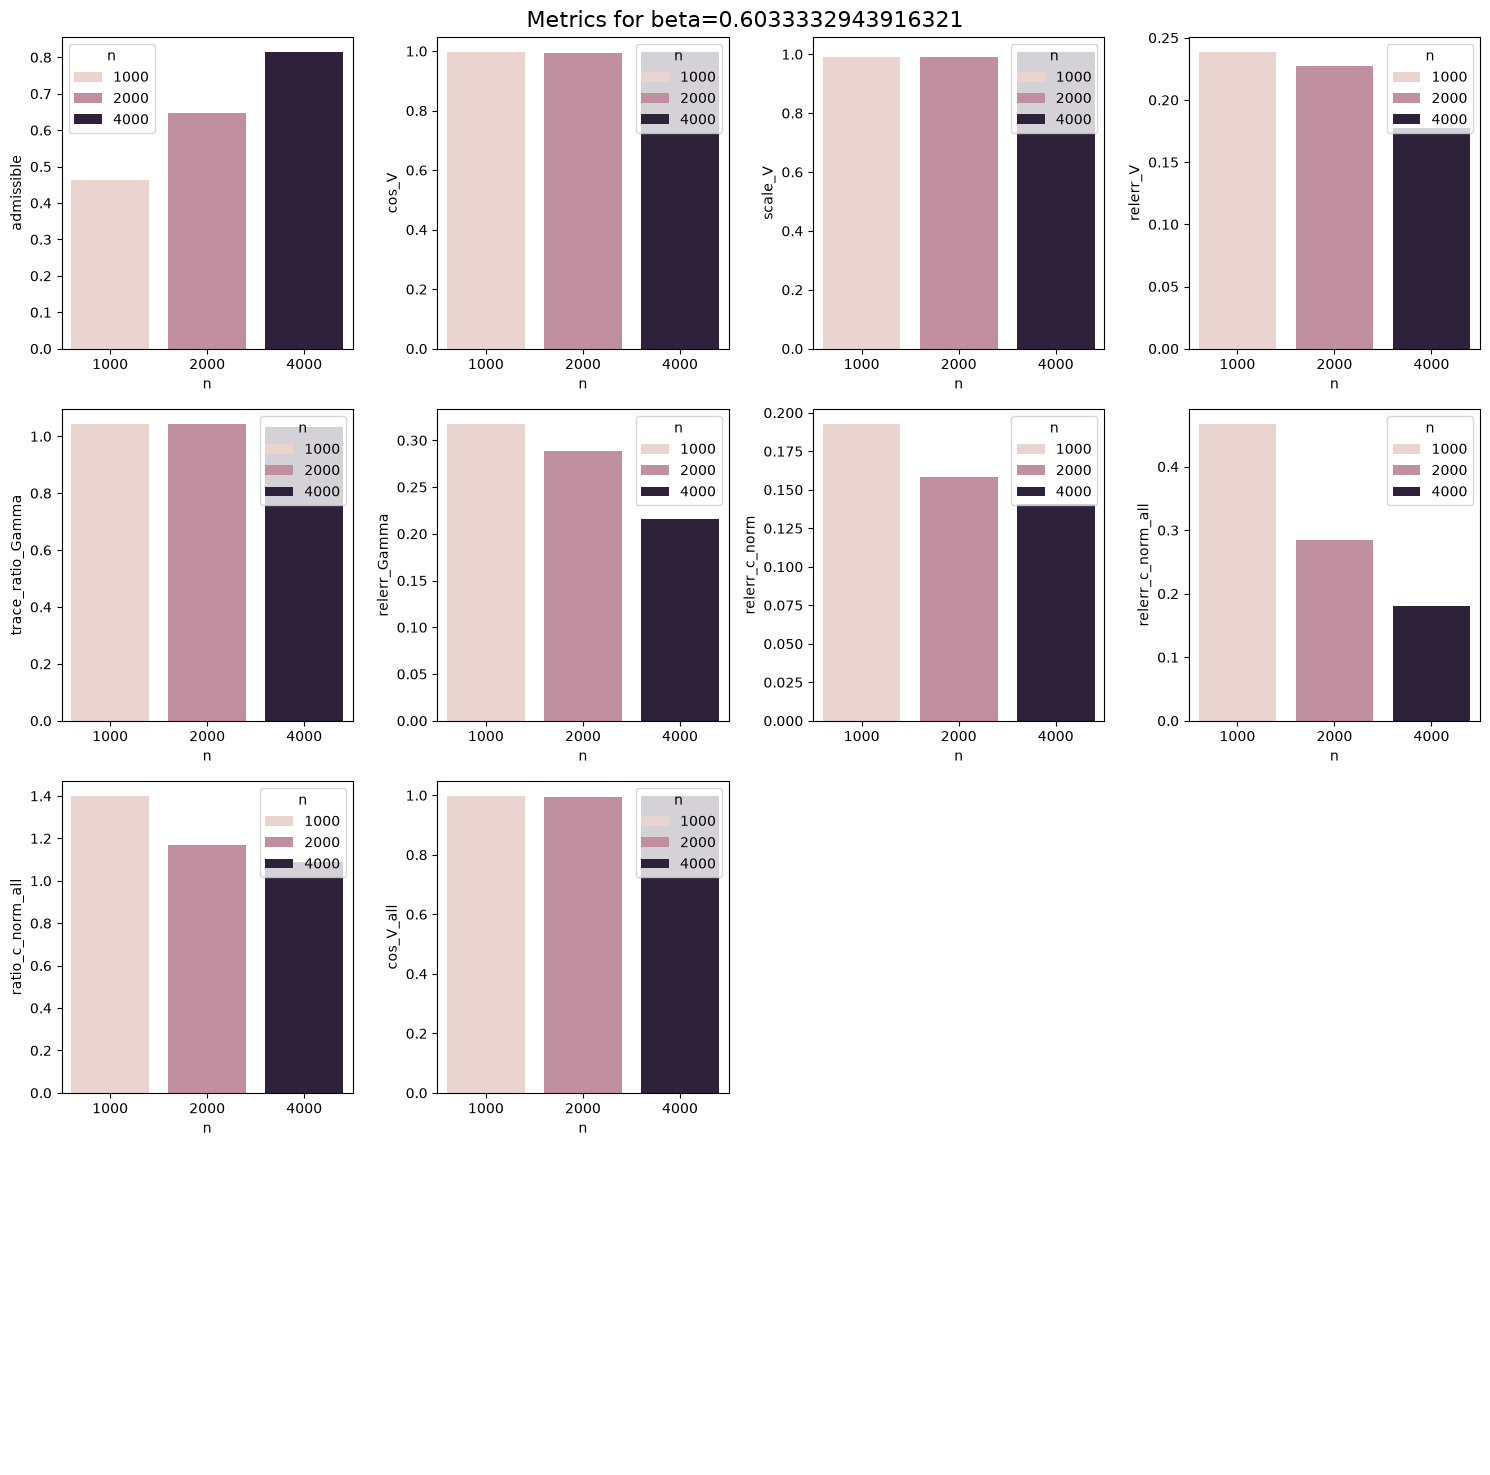

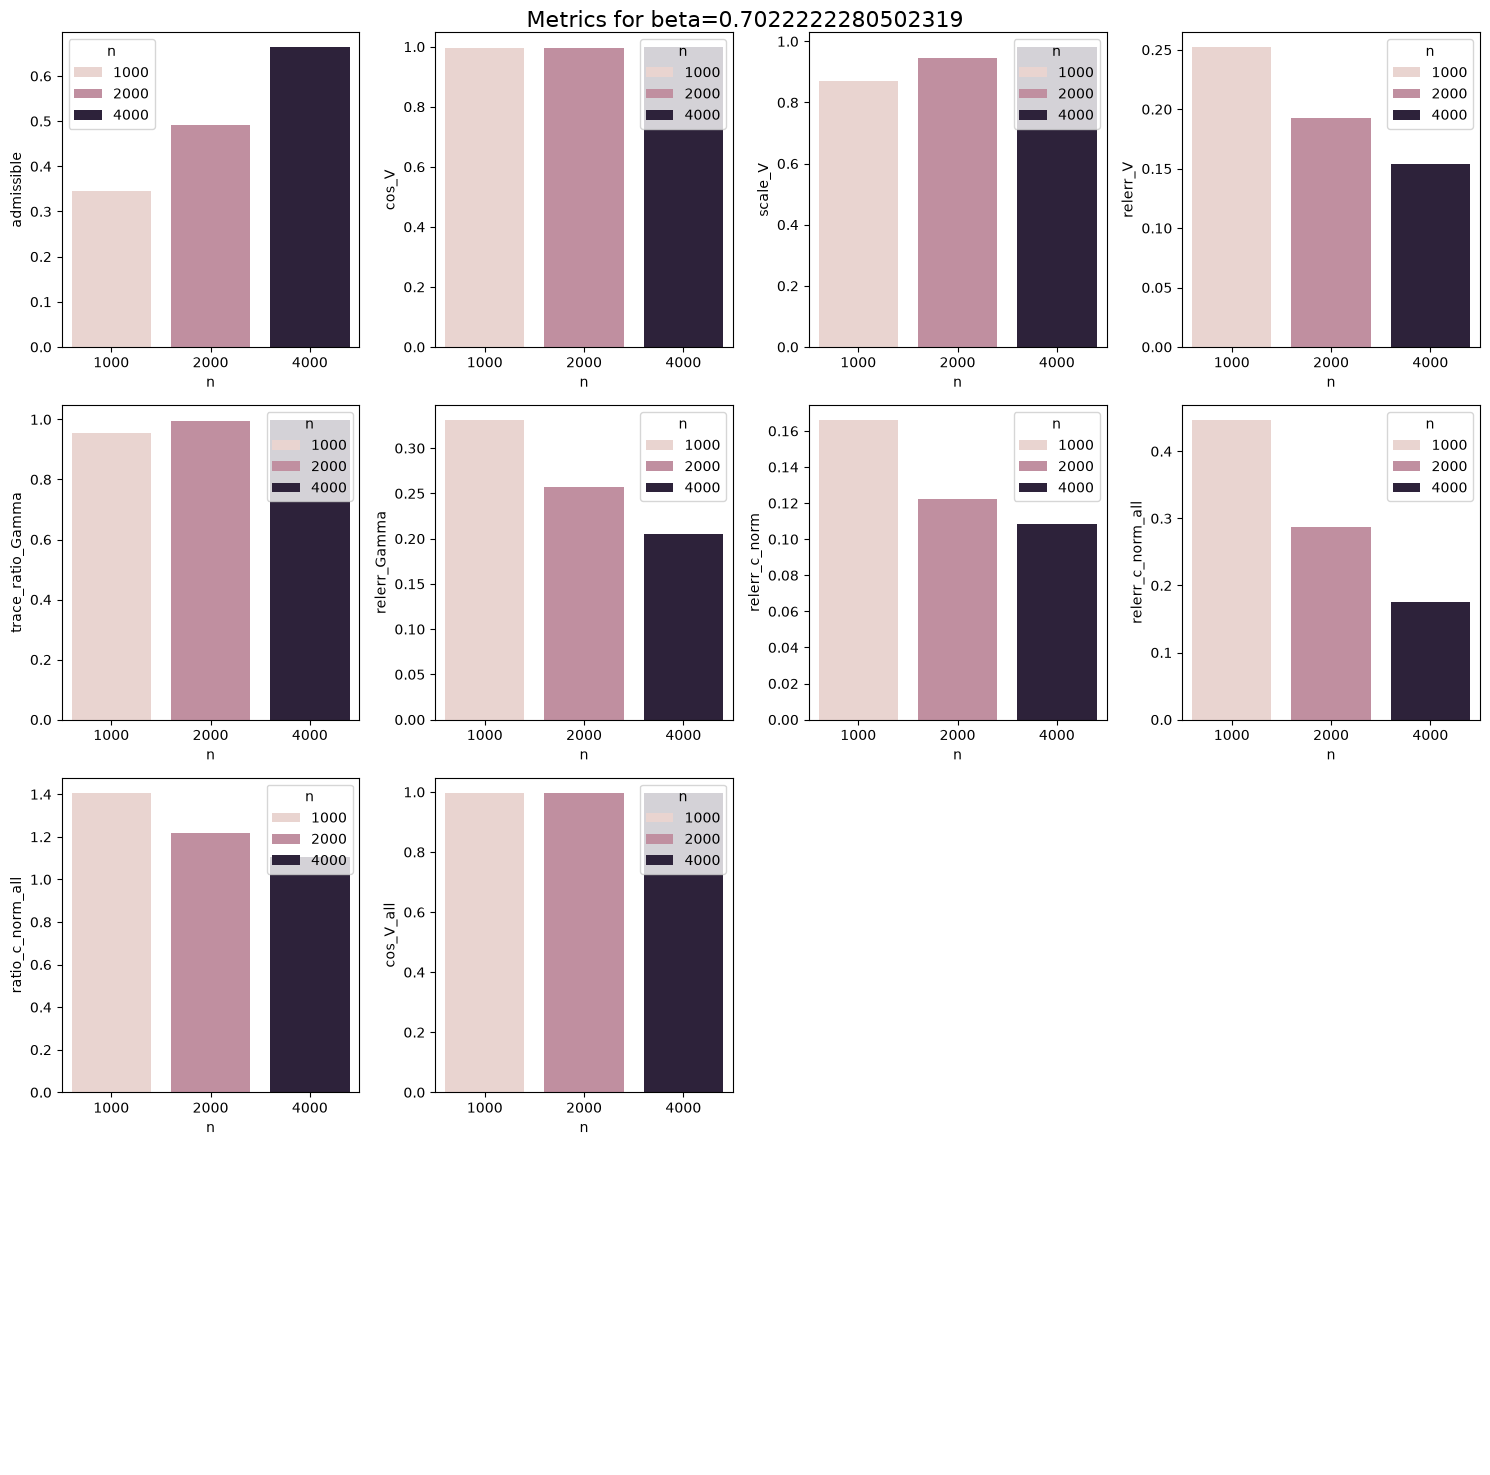

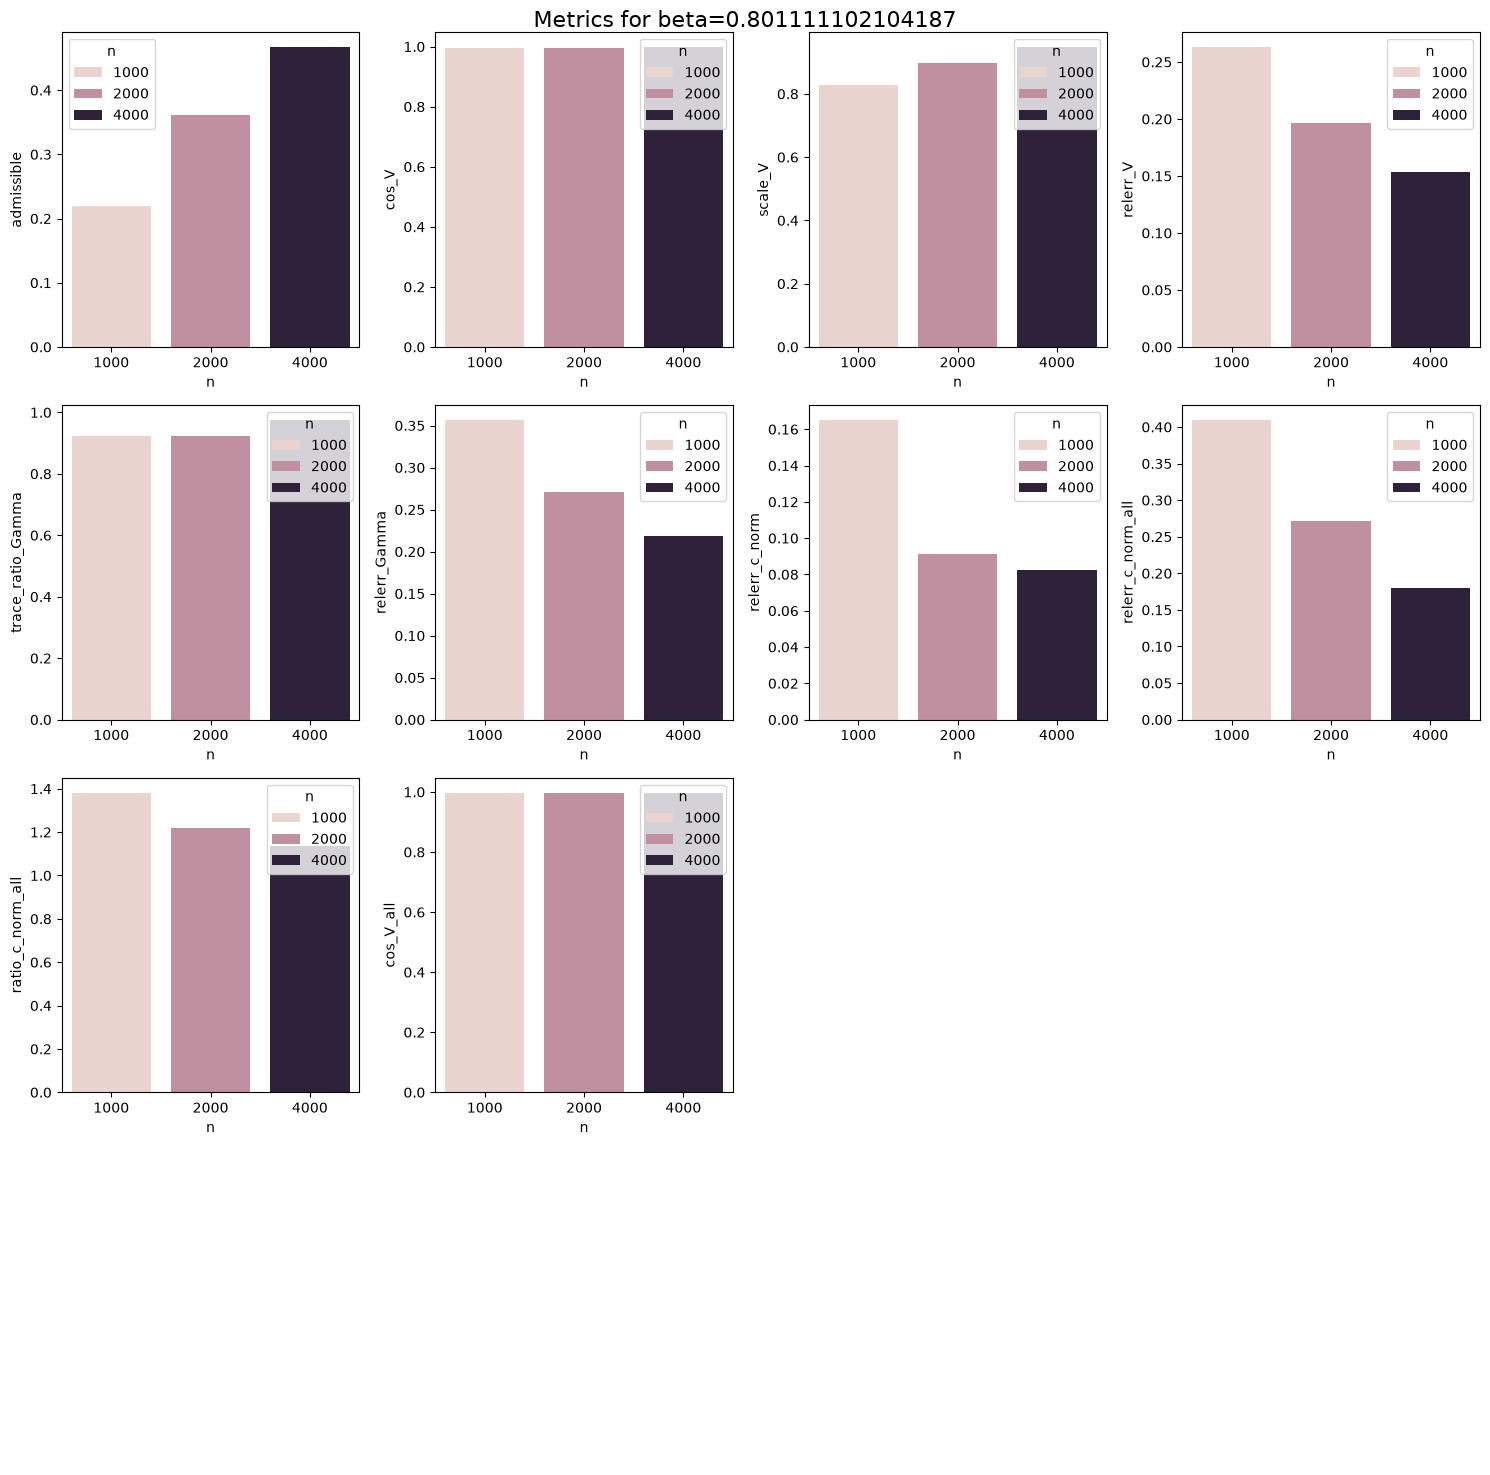

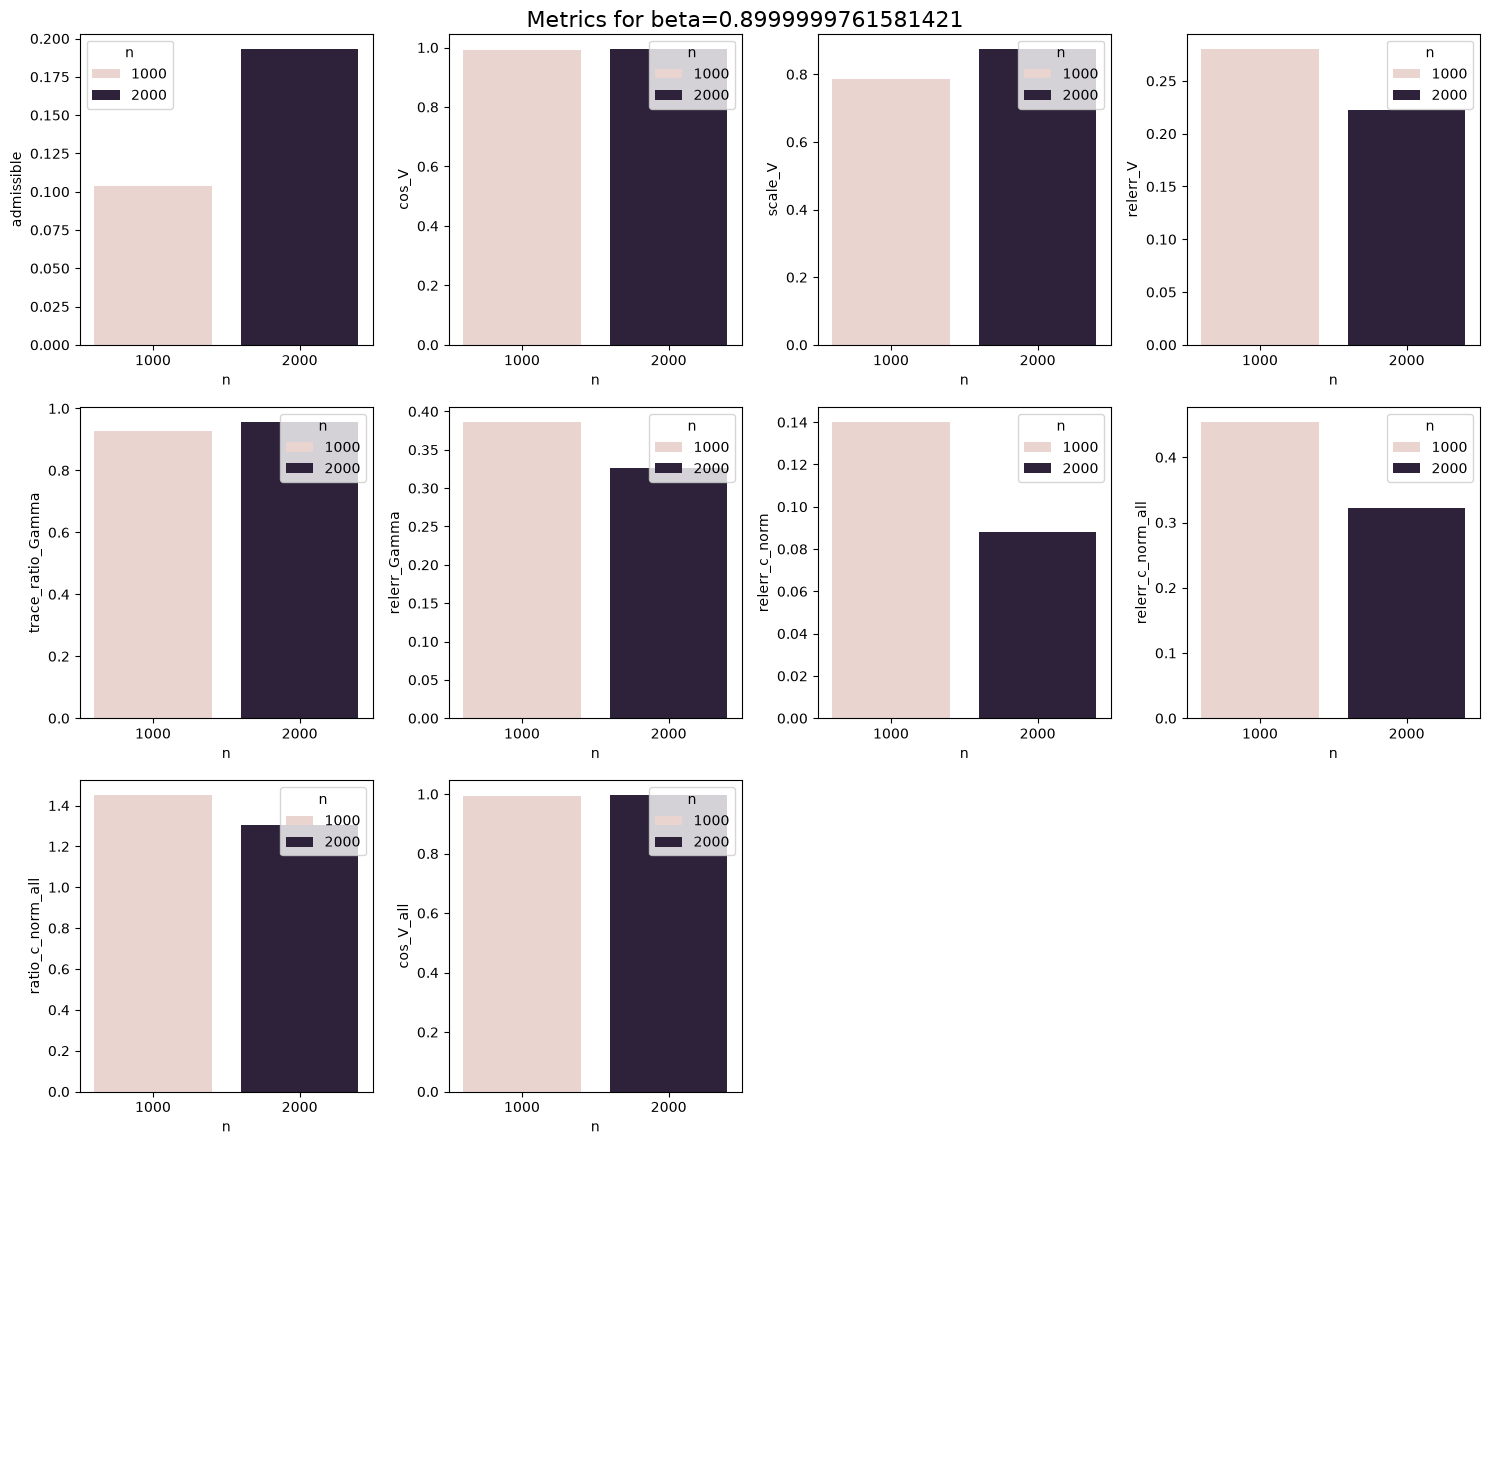

In [97]:
for beta in df_tot['beta'].unique():
    df_tot_beta = df_tot[df_tot['beta'] == beta]
    fig, axes = plt.subplots(squarify(len(col_to_plt)), squarify(len(col_to_plt)), figsize=(15, 15))
    axes = axes.flatten()
    for i in range(len(col_to_plt)):
        sns.barplot(
            data=df_tot_beta,
            x="n",
            y=col_to_plt[i],
            hue="n",
            ax=axes[i]
        )
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f"Metrics for beta={beta}", fontsize=16)
    fig.tight_layout()
    plt.show()

In [100]:
"""
Generate a LaTeX table like "Table 1: Swiss roll" — one grouped column
block per metric (e.g. Rel. err., cos(V, Jc), Admissible), with N values
as sub-columns under each group, and beta as the leading row label.

Expects a "long" dataframe with one row per (beta, n) [or (beta, n, seed)],
and one column per metric.
"""

def make_latex_table(
    df,
    metrics,
    beta_col="beta",
    n_col="n",
    seed_col=None,
    beta_fmt="{:.1f}",
    caption="",
    label="tab:results",
):
    """
    Parameters
    ----------
    df : pd.DataFrame
        Long-format dataframe with columns [beta_col, n_col] (+ seed_col)
        plus one column per metric.
    metrics : list of (col, header, fmt) tuples
        col    -> column name in df holding the metric's values
        header -> LaTeX header for that group, e.g. r"$\\cos(V_i, J_i\\mathbf{c})$"
        fmt    -> python format spec for the numbers, e.g. "{:.2f}"
        Order of this list = left-to-right order of the column groups.
    beta_col, n_col : str
        Names of the grouping columns in df.
    seed_col : str or None
        If given, df has one row per (beta, n, seed) and will be
        median-aggregated over seed_col first (matches "medians over 3 seeds").
    beta_fmt : str
        Format spec for the beta row label.
    caption, label : str
        Table caption / label.

    Returns
    -------
    str : LaTeX source for the table.
    """
    n_values = sorted(df[n_col].unique())
    metric_cols = [m[0] for m in metrics]

    df = (
            df.groupby([beta_col, n_col])[metric_cols]
            .median()
            .reset_index()
        )

    betas = sorted(df[beta_col].unique())
    n_sub = len(n_values)

    col_spec = "c" + " ".join("c" * n_sub for _ in metrics)
    indent = "    "

    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    if caption:
        lines.append(r"\caption{%s}" % caption)
    if label:
        lines.append(r"\label{%s}" % label)
    lines.append(r"\begin{tabular}{%s}" % col_spec)
    lines.append(indent + r"\toprule")

    # --- header row 1: group titles spanning n_sub columns each ---
    header1 = [""]
    for _, header, _ in metrics:
        header1.append(r"\multicolumn{%d}{c}{%s}" % (n_sub, header))
    lines.append(indent + " & ".join(header1) + r" \\")

    # --- cmidrules under each group ---
    cmids = []
    start = 2
    for _ in metrics:
        end = start + n_sub - 1
        cmids.append(r"\cmidrule(lr){%d-%d}" % (start, end))
        start = end + 1
    lines.append(indent + " ".join(cmids))

    # --- header row 2: beta label + "N = 1000  2000  4000" per group ---
    header2 = [r"$\|b\|_{\mathbf{A}^{-1}}$"]
    for _ in metrics:
        for i, nval in enumerate(n_values):
            header2.append(r"$N = %d$" % nval if i == 0 else str(nval))
    lines.append(indent + " & ".join(header2) + r" \\")
    lines.append(indent + r"\midrule")

    # --- body ---
    for b in betas:
        sub = df[df[beta_col] == b].set_index(n_col)
        row = [beta_fmt.format(b)]
        for col, _, fmt in metrics:
            for nval in n_values:
                if nval in sub.index:
                    row.append(fmt.format(sub.loc[nval, col]))
                else:
                    row.append("--")
        lines.append(indent + " & ".join(row) + r" \\")

    lines.append(indent + r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")

    return "\n".join(lines)
print(make_latex_table(
    df_tot,
    metrics=[
        ("relerr_c_norm_all", r"Rel. err. $\|\hat{\mathbf{c}}\|^2_{\hat{g}_{BL}}$", "{:.2f}"),
        ("cos_V_all", r"$\cos(V_i, J_i\mathbf{c})$", "{:.2f}"),
        ("admissible", "Admissible", "{:.2f}"),
    ],
    caption="Swiss roll.",
    label="tab:swiss_roll",
))

\begin{table}[t]
\centering
\caption{Swiss roll.}
\label{tab:swiss_roll}
\begin{tabular}{cccc ccc ccc}
    \toprule
     & \multicolumn{3}{c}{Rel. err. $\|\hat{\mathbf{c}}\|^2_{\hat{g}_{BL}}$} & \multicolumn{3}{c}{$\cos(V_i, J_i\mathbf{c})$} & \multicolumn{3}{c}{Admissible} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(lr){8-10}
    $\|b\|_{\mathbf{A}^{-1}}$ & $N = 1000$ & 2000 & 4000 & $N = 1000$ & 2000 & 4000 & $N = 1000$ & 2000 & 4000 \\
    \midrule
    0.0 & 0.35 & 0.20 & 0.13 & 0.99 & 1.00 & 1.00 & 1.00 & 1.00 & 1.00 \\
    0.1 & 0.39 & 0.24 & 0.14 & 1.00 & 1.00 & 1.00 & 1.00 & 1.00 & 1.00 \\
    0.2 & 0.38 & 0.23 & 0.15 & 0.99 & 0.99 & 1.00 & 0.96 & 1.00 & 1.00 \\
    0.3 & 0.44 & 0.25 & 0.16 & 1.00 & 0.99 & 1.00 & 0.85 & 0.97 & 1.00 \\
    0.4 & 0.42 & 0.24 & 0.16 & 1.00 & 0.99 & 1.00 & 0.78 & 0.91 & 0.98 \\
    0.5 & 0.47 & 0.29 & 0.18 & 1.00 & 0.99 & 1.00 & 0.60 & 0.77 & 0.91 \\
    0.6 & 0.47 & 0.28 & 0.18 & 1.00 & 0.99 & 1.00 & 0.46 & 0.65 & 0.82 \\
    0.7 & 0.45 